In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import mean_squared_error, r2_score
from src.config import DIR_MODEL, LOAD_PROCESSED_DATA, EXPERIMENTS_DIR, RESULTS_DIR

from src.features.build_features import house_price_cleaner, frontage_cleaning

In [12]:

X_train = pd.read_csv(LOAD_PROCESSED_DATA/"X_train_processed.csv")
X_test = pd.read_csv(LOAD_PROCESSED_DATA/"X_test_processed.csv")

y_train = pd.read_csv(LOAD_PROCESSED_DATA/"y_train.csv").squeeze()
y_test = pd.read_csv(LOAD_PROCESSED_DATA/"y_test.csv").squeeze()

In [13]:
best_model = joblib.load(EXPERIMENTS_DIR/ "best_model.pkl")

In [14]:
predictions = best_model.predict(X_test)

In [15]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.12893221559522333
R2 Score: 0.910918878121895


Scatter Plot - Actual VS Predicted values
-

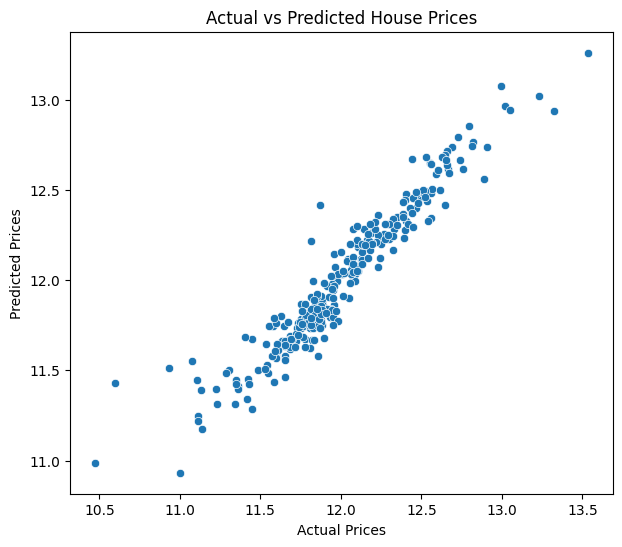

In [16]:
plt.figure(figsize=(7,6))

sns.scatterplot(x=y_test, y=predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.savefig(DIR_MODEL/"ScatterPlots/Actual_vs_predicted_scatter.png")
plt.show()

Scatter Plot - Residual analysis
-

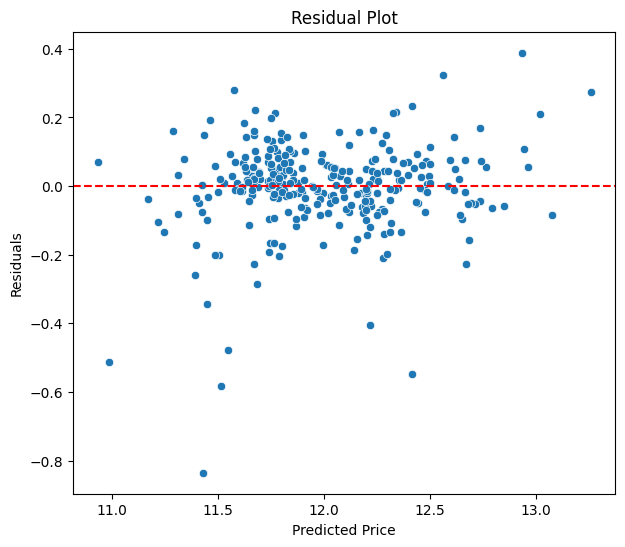

In [17]:
residuals = y_test - predictions

plt.figure(figsize=(7,6))

sns.scatterplot(x=predictions, y=residuals)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig(DIR_MODEL/"ScatterPlots/Residual_plot_scatter.png")


plt.show()

Hist Plot - Residual Distribution
-

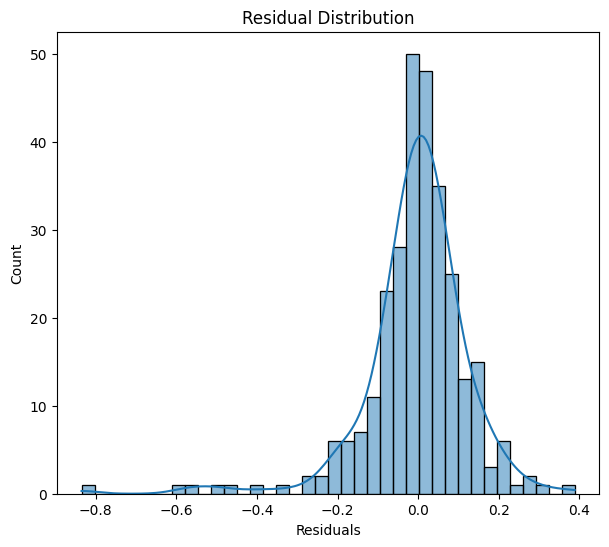

In [18]:
plt.figure(figsize=(7,6))

sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Residual Distribution")

plt.savefig(DIR_MODEL/"histplot/Residual_distribution_histplot.png")


plt.show()

Hist Plot - Prediction Error Distribution
-

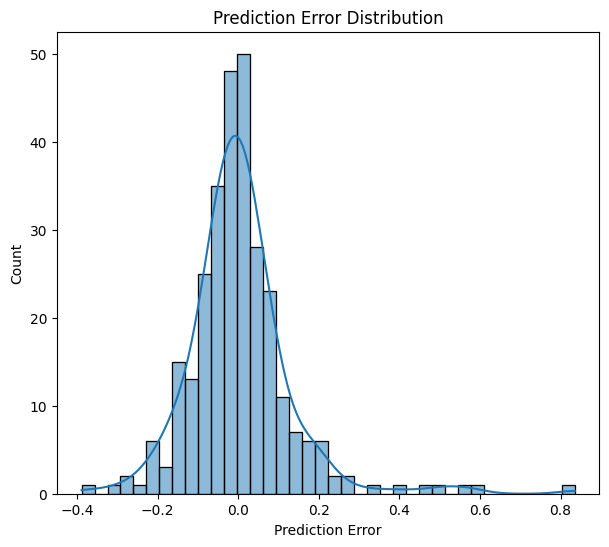

In [19]:
errors = predictions - y_test

plt.figure(figsize=(7,6))

sns.histplot(errors, kde=True)

plt.xlabel("Prediction Error")
plt.title("Prediction Error Distribution")

plt.savefig(DIR_MODEL/"histplot/Prediction_error_distribution_histplot.png")

plt.show()

Bar Plot - Model Comparision
-

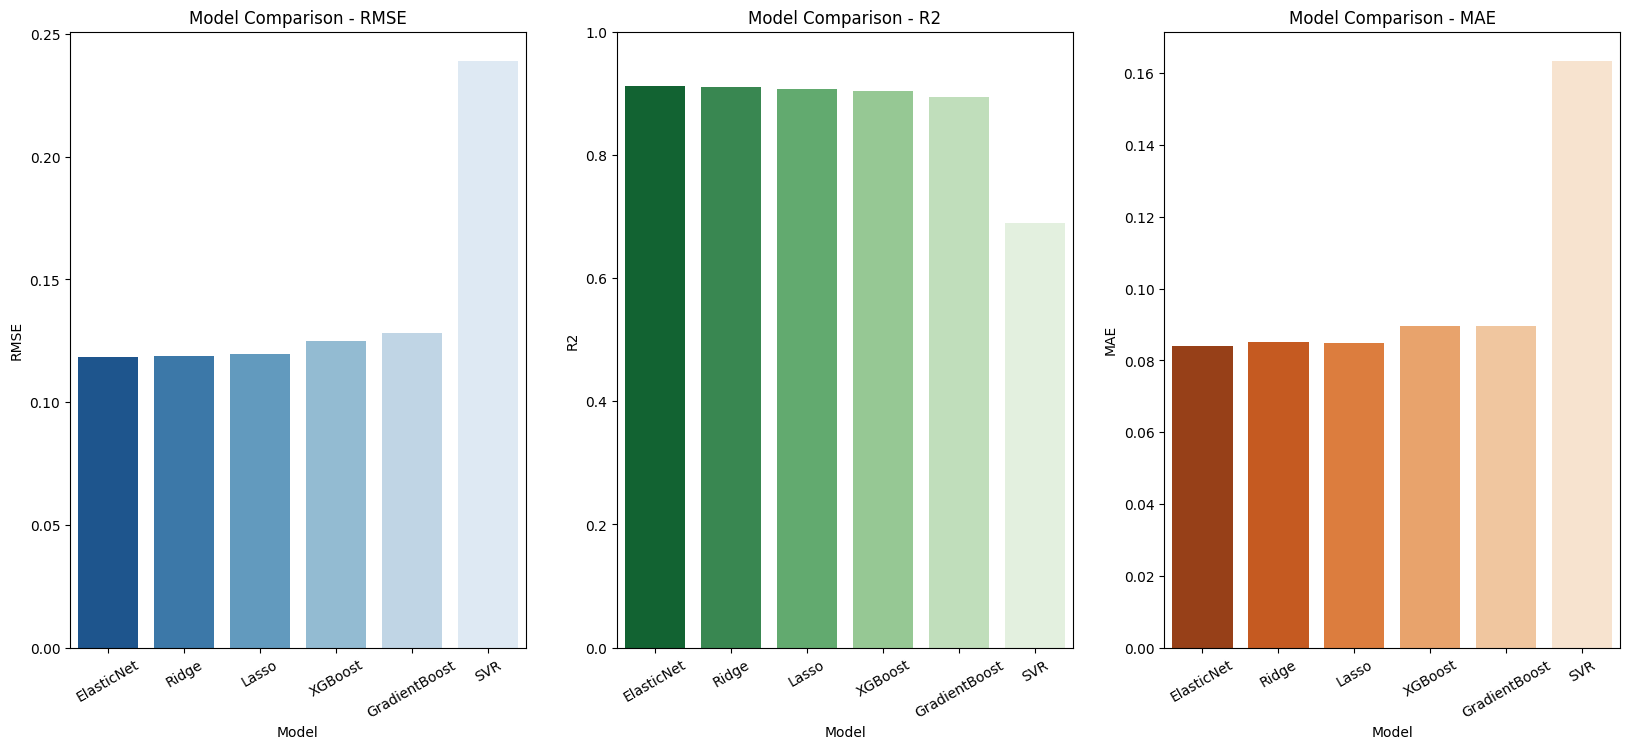

In [20]:
df = pd.read_csv(RESULTS_DIR/"model_comparison.csv")
df = df.sort_values(by="RMSE", ascending=True)

fig, ax = plt.subplots(1, 3, figsize=(20, 8))
sns.barplot(x="Model", y="RMSE", data=df, ax = ax[0], hue = "Model", palette="Blues_r", legend=False)
ax[0].set_title("Model Comparison - RMSE")
ax[0].tick_params(axis='x', rotation=30)
plt.savefig(DIR_MODEL/"barplot/Model_comparison_RMSE_barplot.png")

sns.barplot(x="Model", y="R2", data=df, ax = ax[1], hue = "Model", palette="Greens_r", legend=False)
ax[1].set_title("Model Comparison - R2")
ax[1].set_ylim(0, 1)
ax[1].tick_params(axis='x', rotation=30)
plt.savefig(DIR_MODEL/"barplot/Model_comparison_R2_barplot.png")

sns.barplot(x="Model", y="MAE", data=df, ax = ax[2], hue = "Model", palette="Oranges_r", legend=False)
ax[2].set_title("Model Comparison - MAE")
ax[2].tick_params(axis='x', rotation=30)
plt.savefig(DIR_MODEL/"barplot/Model_comparison_MAE_barplot.png")
plt.show()